# Python Coding Exercise for Module 2, Lesson 1: Linear Regression

Write a Python function that performs LASSO and determine the best regularization hyperparameter using visualization. 

### Your tasks are:

- Write a function named perform_lasso that takes in numpy arrays *X* and *Y* as well as *l* (the regularization hyperparameter, $\lambda$) and returns the lasso model. Use Lasso from sklearn.linear_model.
- Use the cell maked "For testing individual choices of lambda" to determine where to search for the best values of $\lambda$. Use that to determine the best values for *start*, *stop*, and *step* variables to define your grid search of $\lambda$. 
- Use visualization code to pick what you think is the ideal value for $\lambda$. In particular, pay attention to the numpy array *aic_values*, which contains all the AIC scores. Where is the best score? Based on how you are searching for $\lambda$, how can you find the corresponding value of $\lambda$?
- Once you have determined the best LASSO model, find the coefficients, intercept, $R^2$ score, and mean squared error (of the testing sets!) and compare what you found to the ordinary least squares (OLS) linear regression (the "normal" linear regression model we did in Lesson 1). Answer the questions below. 

### Things to Remember:
- Don't use the variable lambda, which is a reserved word in Python for lambda functions. 
- The lowest AIC score is considered the BEST.
- We always build models with the training set, we study hyperparamteres with the validation set, and we score models with the testing set. Make sure your last step is done with the testing set!

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math

In [62]:
# Generation of data
np.random.seed(0)
X = np.random.randn(100, 3)
w_true = np.array([0.5, -1.2, 0], dtype=float)
y = X @ w_true + np.random.randn(100) * 0.5

# Split the data into training and test sets (e.g., 80% train, 20% test)
# Testing is used to evaluate the selected model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the training data further into training and validation sets (e.g., 70% train, 30% validation)
# Validation is used to determine lambda (or any hyperparameter)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

In [63]:
def perform_LASSO(X, Y, l):
    """ Returns the LASSO model trained on X and Y with regularization parameter l"""


In [64]:
# ------- For testing individual choices of lambda ------- 

lasso = perform_LASSO(X_train, y_train, 0.5)

# Print Coefficients
print("Lasso Coefficients:", lasso.coef_)
print("Lasso intercept;", lasso.intercept_ )

# Evaluate the model
test_score = lasso.score(X_test, y_test)
y_predicted_test = lasso.predict(X_test)
mse = mean_squared_error(y_test, y_predicted_test)

#print results
print(f"Testing R-squared: {test_score:.2f}")
print(f"Testing Mean Squared Error: {mse:.4f}")

Lasso Coefficients: [ 0.16411662 -0.80928922  0.        ]
Lasso intercept; -0.0620841528533586
Testing R-squared: 0.74
Testing Mean Squared Error: 0.4129


In [65]:
# ------- Define the Search Space for lambda ------- 

start = 
stop = 
step = 
lambdas = np.arange(start, stop, step)

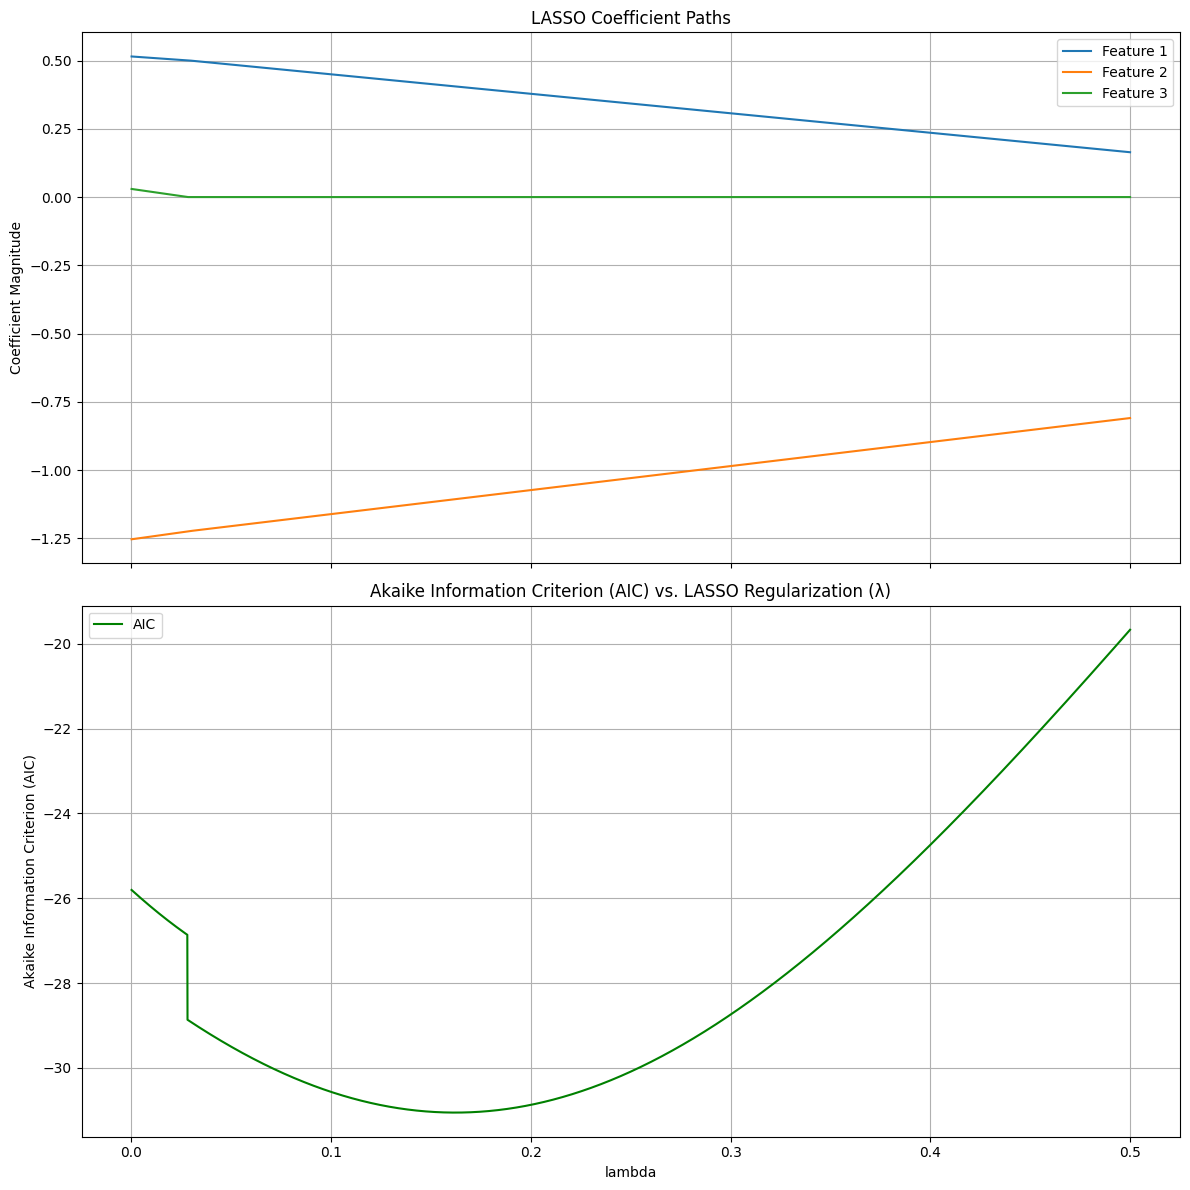

In [66]:
coefs = []
aic_values = []

for l in lambdas:
    lasso = perform_LASSO(X_train, y_train, l)
    coefs.append(lasso.coef_)

    # calculate mean squared error
    y_pred = lasso.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)

    # Calculate AIC
    n = len(y_val)
    rss = mse * n
    k = np.count_nonzero(lasso.coef_)
    aic = n * math.log(rss / n) + 2 * k
    aic_values.append(aic)

# Convert coefficients and AIC values to numpy arrays for easier manipulation
coefficients = np.array(coefs)
aic_values = np.array(aic_values)

# Create a subplot with three plots (coefficient paths, MSE values, and AIC values)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Plot the coefficient paths
for feature in range(X.shape[1]):
    ax1.plot(lambdas, coefficients[:, feature], label=f'Feature {feature + 1}')
ax1.set_ylabel('Coefficient Magnitude')
ax1.set_title('LASSO Coefficient Paths')
ax1.legend()
ax1.grid()

# Plot the AIC values
ax2.plot(lambdas, aic_values, color='green', label='AIC')
ax2.set_xlabel('lambda')
ax2.set_ylabel('Akaike Information Criterion (AIC)')
ax2.set_title('Akaike Information Criterion (AIC) vs. LASSO Regularization (λ)')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

In [67]:
# Find minimum of AIC values and optimal lambda 

print("Optimal lambda:", l)

-31.055764733221444

In [70]:
# Find LASSO model and score it with the testing set

LASSO coefficients: [ 0.40522985 -1.10652121  0.        ]
LASSO intercept: -0.055535554188906884


In [72]:
# Find OLS Linear Regression model and score it with the testing set

OLS Linear Regression coefficients: [ 0.51494965 -1.2534915   0.0297934 ]
OLS Linear Regression intercept: -0.044024351499389804
Testing R-squared for Linear Regression: 0.87
Testing Mean Squared Error for Linear Regression: 0.2068


Once you are done, answer the following questions:

1. What did you find to be the best value for $\lambda$? (Hint: We want AIC to be minimal.)
2. For the optimal $\lambda$ you found in part 1, what is the corresponding model?
3. When you score that model, what is the corresponding $R^2$ value and the mean squared error?
4. How does the $R^2$ value and mean squared error compare to an ordinary least squares linear regression model?
5. Based on your questions for 3 and 4, which model would you choose to use?

Answers:

1. 